# Tugas 1 - Modul K-Means Clustering Country Data

**Nama          :** Sarah Nurul Yakin  
**Mata Kuliah   :** Machine Learning  
**Materi        :** K-Means Clustering  

---

## Deskripsi Tugas

Project ini merupakan implementasi algoritma K-Means Clustering menggunakan dataset Country Data.

Tujuan dari project ini adalah untuk mengelompokkan negara berdasarkan karakteristik ekonomi dan sosial seperti pendapatan negara (income), GDP per kapita (gdpp), kesehatan, inflasi, dan harapan hidup.

Metode clustering digunakan untuk menemukan pola dan kemiripan antar negara tanpa menggunakan label data.

In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [2]:
# Load Dataset
baca = pd.read_csv("../dataset/Country-data.csv")

baca.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
# Informasi Dataset
baca.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


In [4]:
# Memilih Variabel untuk Clustering
baca_x = baca.select_dtypes(include=np.number)

baca_x.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


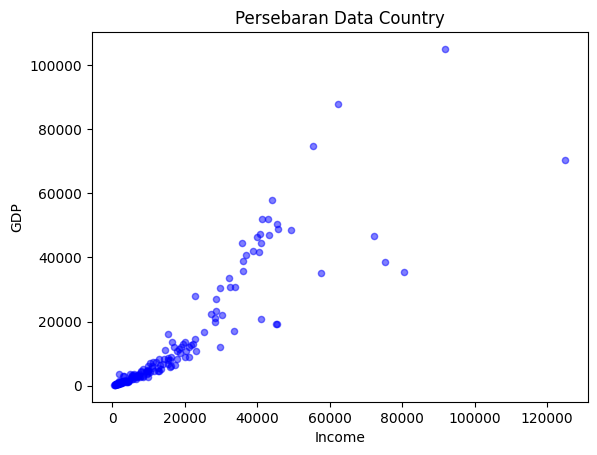

In [5]:
# Visualisasi Persebaran Data
plt.scatter(
    baca['income'],
    baca['gdpp'],
    s=20,
    c='blue',
    alpha=0.5
)

plt.xlabel("Income")
plt.ylabel("GDP")

plt.title("Persebaran Data Country")

plt.show()

In [6]:
# Mengubah Dataframe menjadi Array
x_array = np.array(baca_x)

print(x_array)

[[9.02e+01 1.00e+01 7.58e+00 ... 5.62e+01 5.82e+00 5.53e+02]
 [1.66e+01 2.80e+01 6.55e+00 ... 7.63e+01 1.65e+00 4.09e+03]
 [2.73e+01 3.84e+01 4.17e+00 ... 7.65e+01 2.89e+00 4.46e+03]
 ...
 [2.33e+01 7.20e+01 6.84e+00 ... 7.31e+01 1.95e+00 1.31e+03]
 [5.63e+01 3.00e+01 5.18e+00 ... 6.75e+01 4.67e+00 1.31e+03]
 [8.31e+01 3.70e+01 5.89e+00 ... 5.20e+01 5.40e+00 1.46e+03]]


In [7]:
# Normalisasi Data 
scaler = MinMaxScaler()

x_scaled = scaler.fit_transform(x_array)

x_scaled

array([[0.42648491, 0.04948197, 0.35860783, ..., 0.47534517, 0.73659306,
        0.00307343],
       [0.06815969, 0.13953104, 0.29459291, ..., 0.87179487, 0.07886435,
        0.03683341],
       [0.12025316, 0.1915594 , 0.14667495, ..., 0.87573964, 0.27444795,
        0.04036499],
       ...,
       [0.10077897, 0.35965101, 0.31261653, ..., 0.8086785 , 0.12618297,
        0.01029885],
       [0.26144109, 0.1495365 , 0.20944686, ..., 0.69822485, 0.55520505,
        0.01029885],
       [0.39191821, 0.18455558, 0.25357365, ..., 0.39250493, 0.670347  ,
        0.01173057]], shape=(167, 9))

### Membuat Model K-Means
Model K-Means dibuat dengan jumlah cluster sebanyak 3.

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(x_scaled)

print(kmeans.labels_)

baca["kluster"] = kmeans.labels_

print(baca.head())

[2 0 0 2 0 0 0 1 1 0 0 0 0 0 0 1 0 2 0 0 0 0 0 1 0 2 2 0 2 1 0 2 2 0 0 0 2
 2 2 0 2 0 1 1 1 0 0 0 0 2 2 0 0 1 1 2 2 0 1 2 1 0 0 2 2 0 2 0 1 0 0 0 2 1
 1 1 0 1 0 0 2 2 1 0 2 0 0 2 2 0 0 1 0 2 2 0 0 2 1 2 0 0 0 0 0 0 2 0 2 0 1
 1 2 2 1 0 2 0 0 0 0 0 1 1 0 0 2 0 0 2 0 0 2 1 1 1 0 0 1 1 0 0 2 0 1 1 0 2
 0 2 2 0 0 0 0 2 0 1 1 1 0 0 0 0 0 2 2]
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  kluster  
0       9.44        56.2       5.82    553        2  
1       4.49        76.3       1.65   4090        0  
2      16.10        76.5       2.89   4460        0  
3      22.4

### Report Hasil Clustering 

Evaluasi dilakukan menggunakan accuracy, classification report, dan F1 Score untuk melihat hasil pengelompokan data.

In [9]:
y_pred = kmeans.labels_

y_test = y_pred

print("Accuracy :", accuracy_score(y_test, y_pred))

print(f'Classification Report: \n{classification_report(y_test, y_pred)}')

print(f"F1 Score : {f1_score(y_test, y_pred, average='macro')}")

Accuracy : 1.0
Classification Report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        45

    accuracy                           1.00       167
   macro avg       1.00      1.00      1.00       167
weighted avg       1.00      1.00      1.00       167

F1 Score : 1.0


### Visualisasi Hasil Clustering 


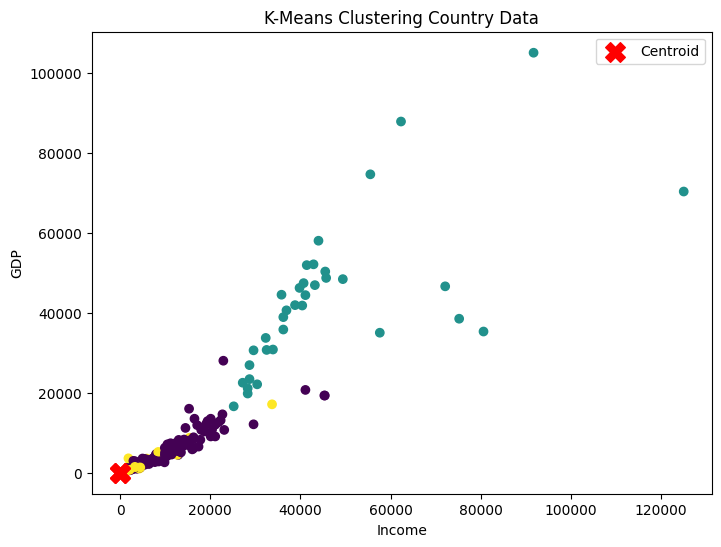

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    baca['income'],
    baca['gdpp'],
    c=baca['kluster'],
    cmap='viridis'
)

plt.scatter(
    kmeans.cluster_centers_[:, 6],
    kmeans.cluster_centers_[:, 8],
    s=200,
    c='red',
    marker='X',
    label='Centroid'
)

plt.xlabel('Income')
plt.ylabel('GDP')

plt.title('K-Means Clustering Country Data')

plt.legend()

plt.savefig("../hasil/visualisasi_cluster_country.png", bbox_inches='tight')

plt.show()

### Menyimpan Hasil Clustering


In [11]:
baca.to_csv("../hasil/hasil_cluster_country.csv", index=False)

print("Hasil clustering berhasil disimpan.")

Hasil clustering berhasil disimpan.


### Menyimpan Ringkasan Cluster 


In [12]:
ringkasan_cluster = baca.groupby("kluster")[["income", "gdpp"]].mean()

print(ringkasan_cluster)

ringkasan_cluster.to_csv("../hasil/ringkasan_cluster_country.csv")

print("Ringkasan cluster berhasil disimpan.")

               income          gdpp
kluster                            
0        12644.482759   6657.379310
1        45802.857143  43117.142857
2         3555.400000   1704.933333
Ringkasan cluster berhasil disimpan.


### Kesimpulan

Berdasarkan percobaan yang telah dilakukan, algoritma K-Means Clustering berhasil diterapkan pada dataset Country Data.

Hasil clustering menunjukkan bahwa negara dapat dikelompokkan berdasarkan karakteristik ekonomi tertentu seperti income dan GDP per kapita.

Cluster yang terbentuk memiliki karakteristik yang berbeda sehingga dapat membantu dalam proses analisis data dan pengambilan keputusan.